# Introdução - Séries Temporais

### O que são Séries Temporais
- Uma série temporal são observações registradas sequencialmente ao longo de um determinado intervalo de tempo.
- Os principais objectivos na análise de séries temporais são entender o comportamento de fenômenos ao longo do tempo, identificar padrões, tendências e sazonalidades e realizar previsões futuras com base em valores passados.
- Exemplos de séries temporais:
    - Finanças: Preços de ações, taxas de câmbio, índices de mercado.
    - Meteorologia: Temperatura, precipitação, humidade.
    - Saúde: Batimentos cardíacos, pressão arterial, níveis de glicose.
    - Vendas: Quantidade de produtos vendidos, faturamento.
    - Tráfego: Número de carros em uma via, velocidade média.

In [1]:
# Algumas bibliotecas serão importadas apenas na célula onde são necessárias,

# Importação de bibliotecas "Gerais"
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Download do dataset das acções da Apple do portal Yahoo Finance (2020 até 2024)
apple_data = yf.download('AAPL', start='2020-01-01', end='2025-01-01')

# Bloco if caso o dataset não tenha sido carregado correctamente.
if apple_data is not None:
    # Criação de um novo dataframe só com os dados de preço de fecho
    apple_data_close = apple_data[['Close']].copy()  # foi usado copy para não alteramos o acidentalmente o df original
else:
    print('Erro: Não foi possível baixar correctamente os dados. Verifique sua ligação.')



YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
# Apresentação das cinco primeiras linhas do dataset
apple_data_close.head()

Price,Close
Ticker,AAPL
Date,
2020-01-02,72.716072
2020-01-03,72.009109
2020-01-06,72.582901
2020-01-07,72.241547
2020-01-08,73.403648


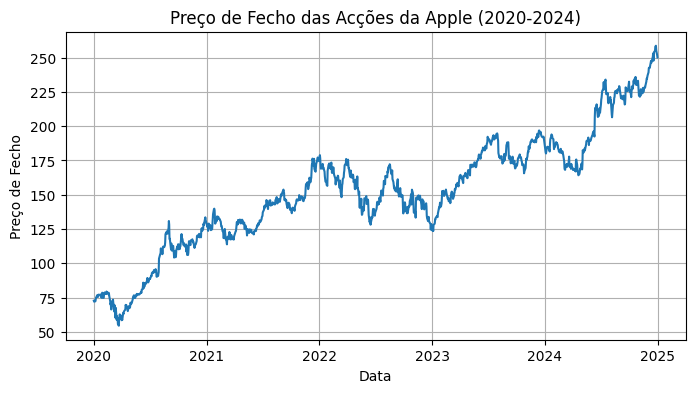

In [4]:
# Exemplo de um gráfico de uma série temporal
plt.figure(figsize=(8, 4))
plt.plot(apple_data_close)
plt.title('Preço de Fecho das Acções da Apple (2020-2024)')
plt.xlabel('Data')
plt.ylabel('Preço de Fecho')
plt.grid(True)
plt.show()

### Características das Séries Temporais

As principais características das séries temporais são:
1. __Tendência__ - A direção geral em que os dados se movem ao longo do tempo, podendo ser ascendente, descendente ou estável;
2. __Sazonalidade__ - Padrões regulares que se repetem em intervalos de tempo fixos, como dias, semanas, meses ou anos;
3. __Ciclicidade__ - Flutuações de longo prazo que não são sazonais, como ciclos económicos;
4. __Resíduos (Irregularidades)__ - As Irregularidades representam as variações aleatórias na série temporal que não podem ser atribuídas a tendência, sazonalidade ou ciclos;
5. __Estacionariedade__ - Uma série temporal é considerada estacionária quando suas propriedades estatísticas (média, variância e autocorrelação) permanecem constantes ao longo do tempo.


Estas características são importantes para entender o comportamento dos dados e escolher o modelo de análise e previsão mais adequado.

#### Tendência
A tendência pode ser facilmente visualmente contudo podemos detectar a tendência com os seguintes métodos:
- Médias Movéis (MA - Moving Mverages);
- Regressão Linear
- Teste de Mann-Kendall

##### Médias Movéis (MA - Moving Mverages)
As Médias Móveis (MAs) identificam as tendências porque "suavizam" os dados, removendo flutuações de curto prazo e destacando a direção geral dos preços.  
As MAs é o cálculo da média dos preços em uma janela de tempo (ex: últimos 30 dias). Isso "corta" o ruído aleatório (volatilidade diária), revelando o movimento subjacente.  
- Tendência Ascendente:
    - Preços estão acima da MA.
    - MA curta está acima da MA longa (ex: MA50 > MA200).
- Tendência Descendente:
    - Preços estão abaixo da MA.
    - MA curta está abaixo da MA longa (ex: MA50 < MA200).
- Tendência Estável:
    - Preços oscilam em torno da MA, sem direção clara.

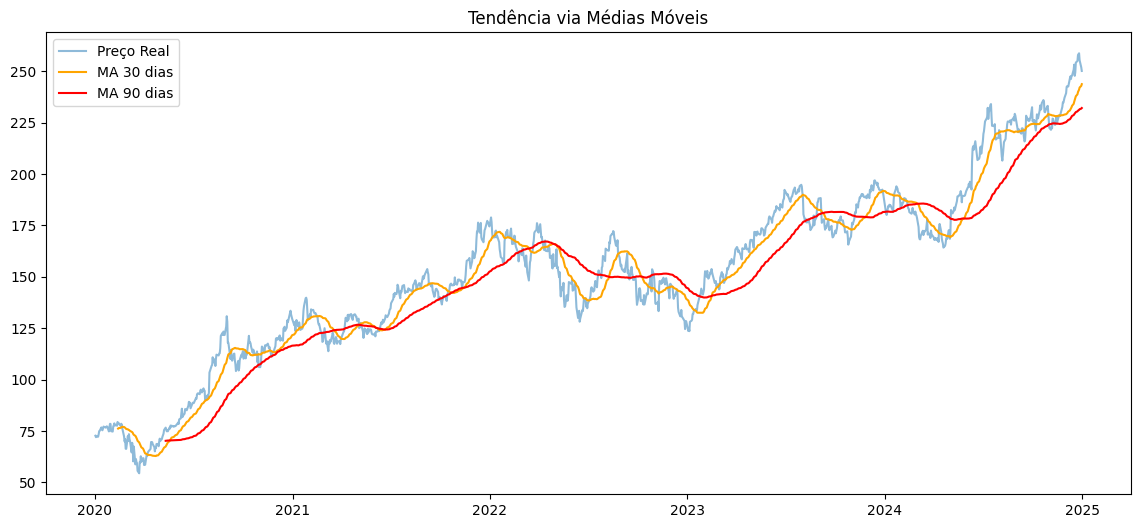

In [5]:
# Médias Movéis (MA - Moving Averages) - Exemplo
# Adição das médias movéis de 30 e 90 dias ao dataframe
apple_data_close['MA_30'] = apple_data_close['Close'].rolling(window=30).mean()
apple_data_close['MA_90'] = apple_data_close['Close'].rolling(window=90).mean()

# Visualização gráfica das Médias Móveis
plt.figure(figsize=(14, 6))
plt.plot(apple_data_close['Close'], label='Preço Real', alpha=0.5)
plt.plot(apple_data_close['MA_30'], label='MA 30 dias', color='orange')
plt.plot(apple_data_close['MA_90'], label='MA 90 dias', color='red')
plt.title('Tendência via Médias Móveis')
plt.legend()
plt.show()

##### Regressão Linear
A regressão linear é uma técnica estatística que modela a relação entre uma variável dependente (ex: preço) e uma variável independente (ex: tempo). Ela identifica a direção e a força da tendência através de uma recta ajustada aos dados.  
Equação da recta ( $y = mx + b$ ):  
- $y$ -> Preço
- $m$ -> Declive
- $x$ -> Tempo
- $b$ -> Origem  

Declive da recta:  
- $m$ > 0: Tendência Ascendente (preço aumenta com o tempo).
- $m$ < 0: Tendência Descendente (preço diminui com o tempo).
- $m$ ≈ 0: Tendência Estável ou ausente.

Valor-p
Medida da significância estatística da tendência, ou seja, é a probabilidade de a hipótese de não haver tendência for verdadeira. Nota o valor-p é usado em vários cenários.  
- $p < 0.05$ -> Tendência estatisticamente significativa
- $p \geq 0.05$ -> Sem evidência de tendência clara

Declive: 0.1062 (USD por dia)
Valor-p: 0.0000
Tendência significativa!


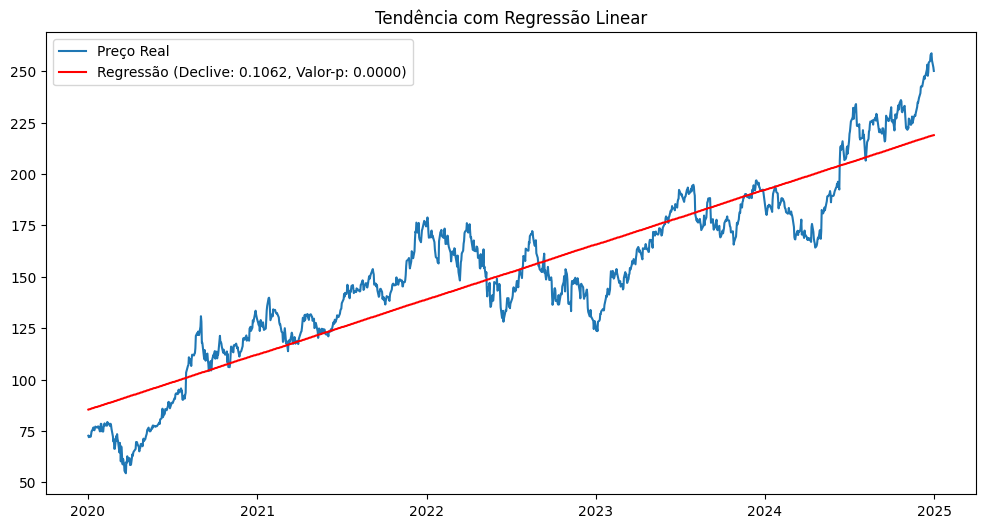

In [6]:
from scipy.stats import linregress

# Criar variável temporal (dias)
dias = np.arange(len(apple_data_close))

# Regressão linear
# Nota foi utilizado o .values.ravel() para transformar a forma do df de (n, 1) para (n,) ou seja array 1D.
modelo = linregress(dias, apple_data_close['Close'].values.ravel())
declive = modelo.slope # type: ignore
p_valor = modelo.pvalue # type: ignore

print(f"Declive: {declive:.4f} (USD por dia)")
print(f"Valor-p: {p_valor:.4f}")

if p_valor < 0.05:
    print("Tendência significativa!")
else:
    print("Sem tendência clara.")

# Visualização gráfica da recta ajustada
plt.figure(figsize=(12, 6))
plt.plot(apple_data_close.index, apple_data_close['Close'], label='Preço Real')
plt.plot(apple_data_close.index, modelo.intercept + declive * dias, color='red',  # type: ignore
         label=f'Regressão (Declive: {declive:.4f}, Valor-p: {p_valor:.4f})')
plt.title('Tendência com Regressão Linear')
plt.legend()
plt.show()

##### Teste de Mann-Kendall
O teste de Mann-Kendall é um método não paramétrico (não assume distribuição específica dos dados) para detectar tendências monotônicas (sempre crescentes ou decrescentes) em séries temporais. É ideal para dados não lineares ou com outliers.    
Funcionamento:
- Para cada par de pontos ($i,j$), onde $i < j$, o teste verifica se $x_j > x_i$ (tendência alta), $x_j < x_i$ (tendência de baixa), ou $x_j = x_i$ (sem tendência);
- Estatística $S$:
    - $S$ = (Nº de pares crescentes) − (Nº de pares decrescentes);
    - Se $S > 0$: Tendência de alta.
    - Se $S < 0$: Tendência de baixa.
- Significância (Valor-p):
    - Calcula-se um valor-p a partir de $S$, para o tamanho da amostra e variância.
        - $Valor-p < 0.05$: Tendência significativa.
        - $Valor-p \geq 0.05$: Sem tendência clara.

In [7]:
import pymannkendall as mk

# Aplicar Mann-Kendall
resultado = mk.original_test(apple_data_close['Close'])

# increasing (crescente), decreasing (decrescente), no trend (sem tendência)
print(f"Tendência: {resultado.trend}")
# Significância
print(f"Valor-p: {resultado.p:.4f}")
# Magnitude da tendência
print(f"Declive: {resultado.slope:.4f}")


Tendência: increasing
Valor-p: 0.0000
Declive: 0.1073


#### Sazonalidade
A sazonalidade representa variações periódicas, previsíveis e recorrentes, vinculadas a ciclos temporais fixos (ex: horas, dias, meses).  
A sazonalidade:
- Repete-se em intervalos regulares (ex: todo dezembro, todo primeiro dia útil do mês);
- Tem causa conhecida ou presumida (ex: balanços trimestrais, pagamento de dividendos, efeitos comportamentais);
- Pode ser aditiva ou multiplicativa:
    - Aditiva - A magnitude do padrão é constante (ex: +5% no volume de negociações toda sexta-feira);
    - Multiplicativa - A magnitude cresce/diminui com o tempo (ex: variações percentuais maiores em períodos de alta volatilidade).
##### Como Detectar Sazonalidade
Visualização com Decomposição STL:
- A decomposição STL (Seasonal-Trend decomposition using Loess) é uma técnica avançada para decompor uma série temporal em três componentes:
    - Tendência (Trend): Movimento de longo prazo, livre de sazonalidade e ruído;
    - Sazonalidade (Seasonal): Padrões periódicos e repetitivos (ex: variações mensais);
    - Resíduo (Residual): Variações não explicadas (ruído aleatório ou eventos atípicos).
- Razões para usar STL:
    - Flexibilidade: Lida com sazonalidade não constante (ex: magnitude que varia ao longo do tempo);
    - Robustez: Suporta outliers (ideal para séries financeiras voláteis);
    - Controle de Parâmetros: Permite ajustar a "suavização" da tendência e sazonalidade via seasonal_period e seasonal_degree.

In [8]:
# Neste exemplo vamos usar dados da Petrobras
# Outra maneira de verificar se o download dos dados é bem sucedida (bloco try-except)
try:
    petr4_data = yf.download('AAPL', start='2020-01-01', end='2025-01-01')
    petr4_data_close = petr4_data[['Close']].copy() # type: ignore
except Exception as e:
    print(f"Ocorreu um erro ao obter os dados: {e}")
    petr4_data_close = None

# Média mensal para simplificar
petr4_media_mensal = petr4_data_close.resample('ME').mean()   # type: ignore


[*********************100%***********************]  1 of 1 completed


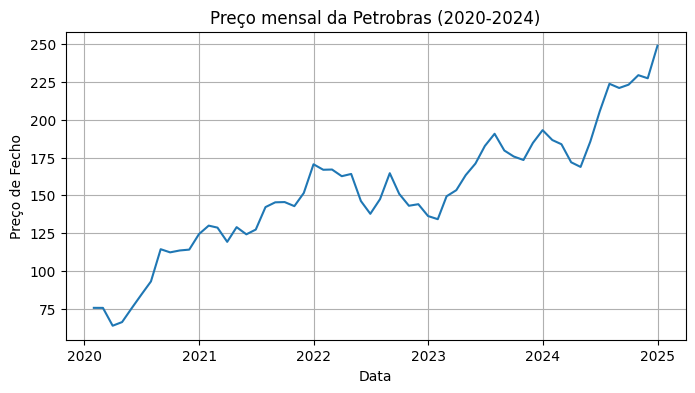

In [9]:
# Visualização gráfica das Acções da Petrobras
plt.figure(figsize=(8, 4))
plt.plot(petr4_media_mensal)
plt.title('Preço mensal da Petrobras (2020-2024)')
plt.xlabel('Data')
plt.ylabel('Preço de Fecho')
plt.grid(True)
plt.show()

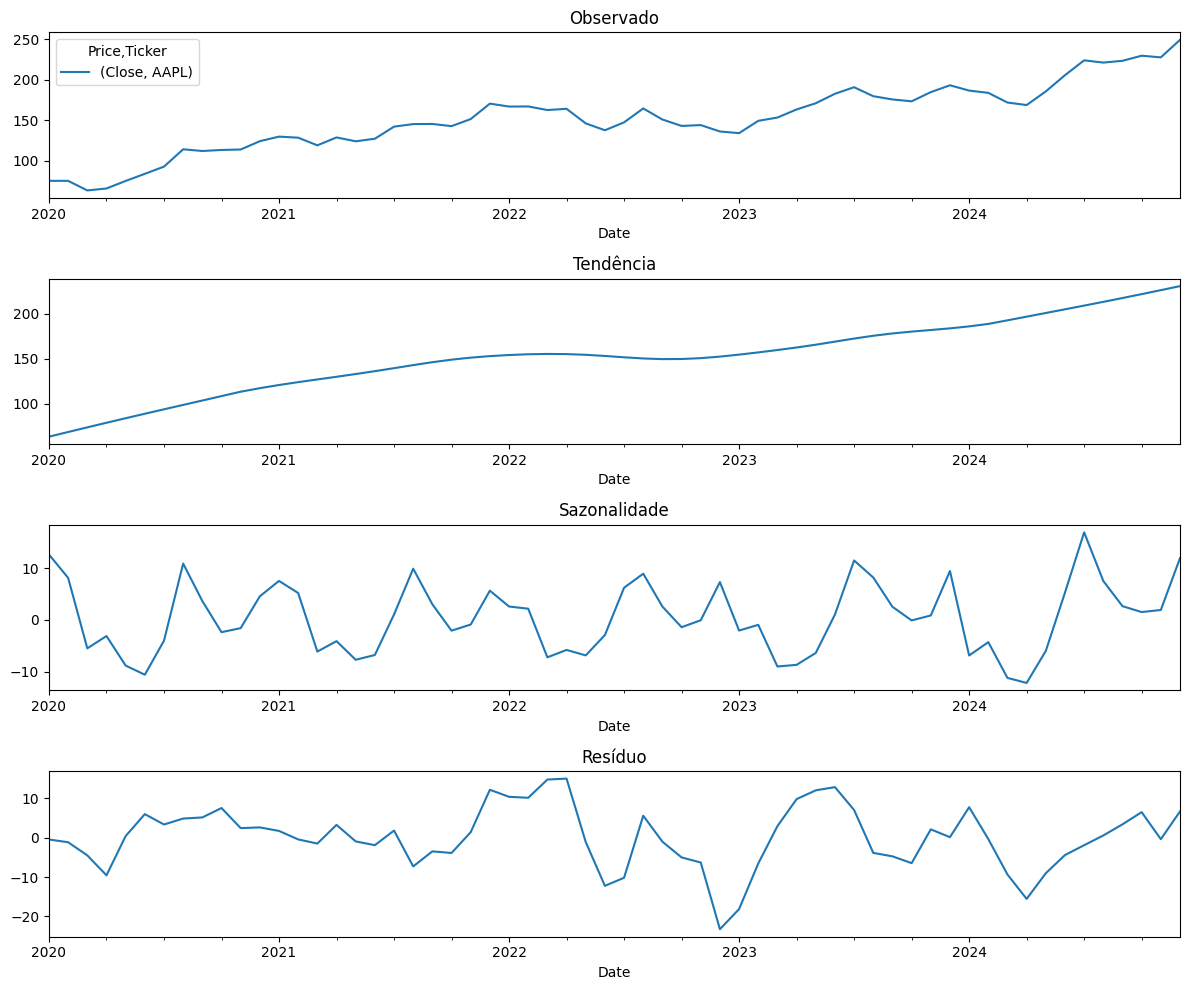

In [10]:
from statsmodels.tsa.seasonal import STL

# Decomposição STL (period=12 para mensal)
stl = STL(petr4_media_mensal, period=12, seasonal=13)
decomp_stl = stl.fit()

# Visualização gráfica da Decomposição STL
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10))
decomp_stl.observed.plot(ax=ax1, title='Observado')
decomp_stl.trend.plot(ax=ax2, title='Tendência')
decomp_stl.seasonal.plot(ax=ax3, title='Sazonalidade')
decomp_stl.resid.plot(ax=ax4, title='Resíduo')
plt.tight_layout()
plt.show()

Observações:
 - É visível que existem momentos de subida e de descida que se repetem ao longo dos anos. Podemos verificar que o preço das acções diminui na Primavera e no Outuno e aumenta no Verão e Inverno.  
- Esta oscilação pode estar parcialmente relacionada à demanda de energia, que tende a ser influenciada pelas estações do ano.  
- Embora a análise sazonal possa fornecer insights valiosos, é importante lembrar que o mercado financeiro é complexo e influenciado por muitos fatores.

#### Ciclicidade
A ciclicidade refere-se a flutuações recorrentes em séries temporais que não seguem um intervalo fixo (ao contrário da sazonalidade) e estão ligadas a fatores externos como ciclos econômicos, políticas governamentais ou comportamentos de mercado.
- Duração variável: Ciclos podem durar meses, anos ou décadas (ex: ciclos de commodities como petróleo).
- Causas complexas: Inflação, taxas de juros, crises geopolíticas, ou inovações tecnológicas.  

Exemplo em finanças:
- Ciclo de alta de 5-7 anos em ações de energia ligado ao preço do barril de petróleo.
- Oscilações em ações de varejo associadas a ciclos de consumo pós-recessão.

1. Decomposição Tendência-Ciclo (Hodrick-Prescott, linha verde)  
O Filtro Hodrick-Prescott (HP) é uma técnica estatística usada para decompor uma série temporal em duas componentes:
    - Tendência - Representa a componente de longo prazo da série, capturando o crescimento ou declínio geral;
    - Ciclo - Representa as flutuações de curto prazo em torno da tendência, indicando desvios da trajetória de longo prazo.

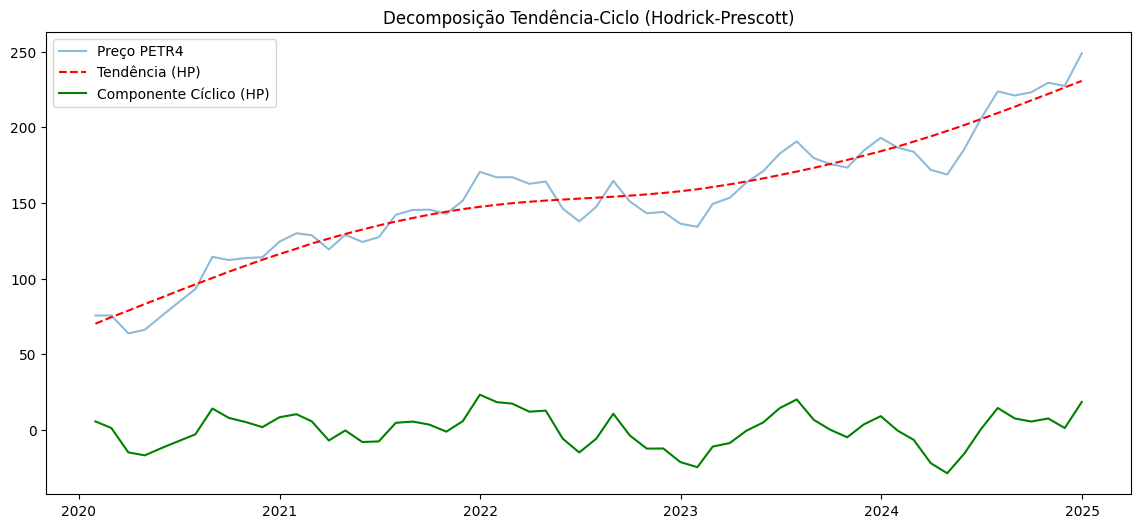

In [11]:
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.filters.bk_filter import bkfilter

# Aplicar HP Filter para separar tendência e ciclo
ciclo_hp, tendencia_hp = hpfilter(petr4_media_mensal, lamb=1600)

# Visualização gráfica da Decomposição Tendência-Ciclo
plt.figure(figsize=(14, 6))
plt.plot(petr4_media_mensal.index, petr4_media_mensal, label="Preço PETR4", alpha=0.5)
plt.plot(petr4_media_mensal.index, tendencia_hp, label="Tendência (HP)", color="red", linestyle="--")
plt.plot(petr4_media_mensal.index, ciclo_hp, label="Componente Cíclico (HP)", color="green")
plt.title("Decomposição Tendência-Ciclo (Hodrick-Prescott)")
plt.legend()
plt.show()

Observações
- Oscila em torno de zero, com valores positivos e negativos;
- Indica os períodos em que o preço da PETR4 está acima ou abaixo da sua tendência de longo prazo;
- Em 2020, mostra valores negativos, refletindo o impacto da pandemia no preço das ações;
- A partir de 2021, alterna entre períodos positivos e negativos, indicando as flutuações do mercado.

2. Filtro Baxter-King
- É uma técnica de estatística usada para isolar os ciclos de curto prazo (1-3 anos);
- O Filtro Baxter-King é útil para identificar flutuações cíclicas em séries temporais, removendo tendências de longo prazo e ruídos.

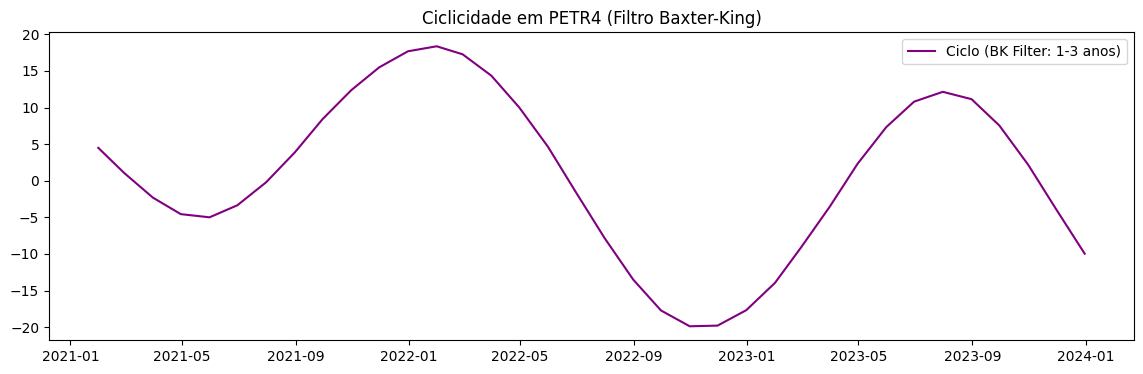

In [12]:
# Converter para frequência mensal (mais estável para ciclos)
dados_mensais = petr4_data_close.resample("ME").last() # type: ignore

# Aplicar filtro Baxter-King para ciclos entre 12 e 36 meses (1-3 anos)
ciclo_bk = bkfilter(dados_mensais, low=12, high=36)

# Visualização gráfica Baxter-King
plt.figure(figsize=(14, 4))
plt.plot(ciclo_bk, label="Ciclo (BK Filter: 1-3 anos)", color="purple")
plt.title("Ciclicidade em PETR4 (Filtro Baxter-King)")
plt.legend()
plt.show()

Observações:
- O gráfico exibe um padrão cíclico, com altos e baixos recorrentes. Isso sugere que o preço da PETR4 experimenta flutuações cíclicas de curto prazo;
- A amplitude dos ciclos (a diferença entre os picos e vales) parece variar, sugerindo que a intensidade das flutuações cíclicas muda ao longo do tempo;
- A distância entre os picos e vales permite estimar a frequência dos ciclos (entre 1 e 3 anos).
- O gráfico permite visualizar os ciclos de alta e baixa, com seus respectivos períodos de duração e amplitude.

3. Análise Espectral de Ciclicidade  
- A Análise Espectral, ou Análise de Fourier, é uma técnica que decompõe uma série temporal em suas frequências constituintes. Em vez de analisar a série no domínio do tempo, ela analisa a série no domínio da frequência.

- Eixos:
    - Eixo Vertical (Potência Espectral) - Representa a magnitude da potência de cada frequência, indicando o quão presente essa frequência está nos dados originais;
    - Eixo Horizontal (Período em anos) - Representa o período dos ciclos em anos, ou seja, o tempo que leva para um ciclo completo ocorrer.

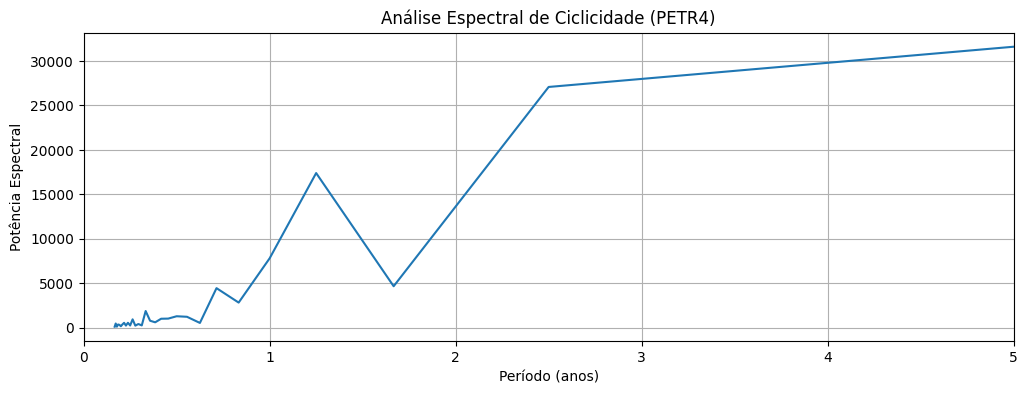

In [13]:
from scipy.signal import periodogram

# Converter dados_mensais para Series (1D) e remover NaNs
dados_mensais_series = dados_mensais.squeeze()  # Converte DataFrame para Series
dados_mensais_clean = dados_mensais_series.dropna()  # Remove NaNs

# Calcular periodograma (retorna frequências e potência como arrays 1D)
frequencias, potencia = periodogram(dados_mensais_clean, fs=1)

# Remover frequência zero para evitar divisão por zero e calcular períodos
frequencias = frequencias[1:]  # Ignora a primeira frequência (0)
potencia = potencia[1:]  # Ajusta o array de potência
periodos = 1 / frequencias / 12  # Período em anos (dados mensais)

# Visualização gráfica  da Análise Espectral de Ciclicidade
plt.figure(figsize=(12, 4))
plt.plot(periodos, potencia)
plt.xlim(0, 5)  # Focar em ciclos até 5 anos
plt.xlabel("Período (anos)")
plt.ylabel("Potência Espectral")
plt.title("Análise Espectral de Ciclicidade (PETR4)")
plt.grid(True)
plt.show()

Observações

Picos:  
- O gráfico mostra dois picos principais, indicando a presença de ciclos dominantes nos preços da PETR4:  
- O primeiro pico, em torno de 1 ano, sugere a presença de um ciclo de curto prazo;  
- O segundo pico, em torno de 3 anos, indica a presença de um ciclo de médio prazo.  

Tendência:
 - Observa-se um aumento da potência espectral com o aumento do período, o que pode indicar a presença de tendências de longo prazo nos dados.

#### Resíduos (Irregularidades)

Resíduos são a parte não explicada da série temporal após removermos tendência, sazonalidade e ciclicidade.  
Estes representam:
- Ruído aleatório (variações não sistemáticas);
- Eventos atípicos (ex: quedas bruscas por crises);
- Falhas do modelo (se o modelo não identificou padrões existentes).

Os resíduos são a "impressão digital" do desempenho do modelo. Analisar suas propriedades é crucial para:  
- Validar suposições estatísticas;
- Detectar anomalias e padrões não modelados;
- Melhorar a acurácia de previsões.

Se os resíduos forem:  
- Aleatórios - O modelo capturou todos os padrões;
- Normais - As previsões são estatisticamente confiáveis;
- Homocedásticos - A incerteza é constante no tempo.

##### Propriedades dos Resíduos

1. Aleatórios (sem autocorrelação)
    - Os resíduos não devem ter padrões ou correlações temporais. Se houver autocorrelação, significa que o modelo deixou de capturar informações estruturadas (ex: sazonalidade não modelada);
    - Modelos como ARIMA e SARIMAX assumem que os resíduos são ruído branco (não correlacionados);
    - Autocorrelação residual indica que o modelo pode ser melhorado.

c:\Users\utilizador\Desktop\Time Series\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


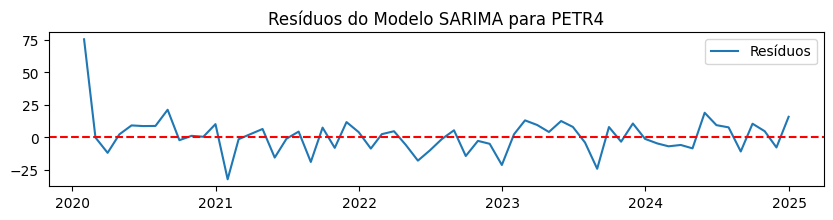

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Modelo SARIMA (exemplo simplificado)
modelo = SARIMAX(petr4_media_mensal, order=(1,1,1), seasonal_order=(1,1,1,12))
resultado = modelo.fit(disp=False)

# Extrair resíduos
residuos = resultado.resid  # type: ignore

# Visualização dos Resíduos
plt.figure(figsize=(10, 2))
plt.plot(residuos, label='Resíduos')
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos do Modelo SARIMA para PETR4')
plt.legend()
plt.show()

Observações:
- Os resíduos parecem estar distribuídos de forma relativamente aleatória em torno da linha zero;
- Não há padrões óbvios ou tendências visíveis nos resíduos;
- A distribuição aleatória e a variabilidade constante dos resíduos sugerem que o modelo SARIMA está se ajustando bem aos dados.

Gráficos de autocorrelação (ACF) e de autocorrelação parcial (PACF)  

Os gráficos ACF e PACF são representações gráficas da correlação entre uma variável e seus valores defasados (lags): 
 - Uma defasagem é o número de períodos de tempo que separam duas observações. Por exemplo, se você tem dados mensais, o primeiro atraso é de um mês, o segundo atraso é de dois meses e assim por diante;
 - A ACF mede a correlação entre uma variável e seus valores defasados, enquanto a PACF mede a correlação entre uma variável e seus valores defasados após remover o efeito de outras defasagens;
 - Os gráficos de ACF e PACF mostram os coeficientes de correlação para diferentes defasagens no eixo vertical e as defasagens no eixo horizontal.

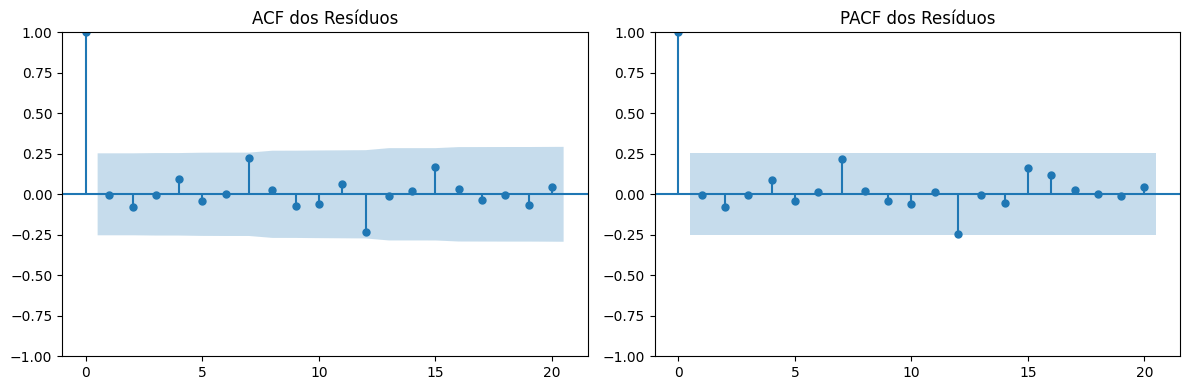

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Visualização dos Gráficos ACF e PACF
# Cria uma figura com 2 subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico ACF
plot_acf(residuos, lags=20, alpha=0.05, ax=ax1)
ax1.set_title('ACF dos Resíduos')

# Gráfico PACF
plot_pacf(residuos, lags=20, alpha=0.05, ax=ax2)
ax2.set_title('PACF dos Resíduos')

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
  
plt.show()

# Nenhum lag deve ser significativo (fora da área sombreada)


Observações  
- Em ambos os gráficos a área azul sombreada representa o intervalo de confiança;
- Todos os pontos estão dentro da área azul, o que sugere que não há autocorrelação significativa nos resíduos;
- Os gráficos ACF e PACF dos resíduos do modelo SARIMA para PETR4 indicam que o modelo está bem ajustado aos dados.

Teste Ljung-Box  
O Teste de Ljung-Box é uma ferramenta estatística para verificar a presença de autocorrelação em séries temporais. Este teste permite identificar se os resíduos de um modelo de regressão são independentes. A independência dos resíduos é uma suposição crucial em muitos modelos estatísticos, e a violação dessa suposição pode levar a inferências incorretas.

In [16]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Todos os valores devem ser > 0.05 
p_valores = acorr_ljungbox(residuos, lags=10).lb_pvalue
print('p-valores:')  
print(p_valores) 

p-valores:
1     0.960927
2     0.814984
3     0.938170
4     0.909416
5     0.951986
6     0.980480
7     0.712653
8     0.798508
9     0.832962
10    0.870654
Name: lb_pvalue, dtype: float64


Observações:  

- Todos os p-valores são significativamente maiores que 0,05;
- Não há evidência estatística suficiente para rejeitar a hipótese nula de que os resíduos são independentes;
- Os resíduos provavelmente são ruído branco (independentes e aleatórios) e o modelo se ajusta bem aos dados.

Atenção:  
- A autocorrelação significativa no lag 1 é um sinal de que o modelo pode não ser perfeito;
- Embora os resultados gerais sejam positivos, é importante considerar a possibilidade de melhorias para capturar completamente a dinâmica dos dados.

2. Distribuição normal (média zero, simétricos)

    Para detectar uma distribuição normal nos resíduos podemos usar métodos visuais tais como:
    - Histograma - Se os resíduos forem normalmente distribuídos, o histograma deve ter uma forma de sino simétrica;
    - Gráfico Q-Q (Quantile-Quantile):
        - Um gráfico Q-Q compara os quantis dos resíduos com os quantis de uma distribuição normal teórica;
        - Se os resíduos forem normalmente distribuídos, os pontos no gráfico Q-Q devem se alinhar aproximadamente em uma linha reta.

    Podemos também utilizar métodos estatísticos:
    - Teste de Shapiro-Wilk ou Anderson-Darling:
        - Testes estatísticos para verificar a normalidade de uma amostra;
        - A hipótese nula do teste é que a amostra é proveniente de uma distribuição normal.
    - Teste de Kolmogorov-Smirnov:
        - Teste estatístico que compara a distribuição empírica dos resíduos com uma distribuição normal teórica;
        - A hipótese nula do teste é que as duas distribuições são iguais.

    Sendo o recomendado utilizar uma combinação de ambos os métodos para avaliar a normalidade dos resíduos.

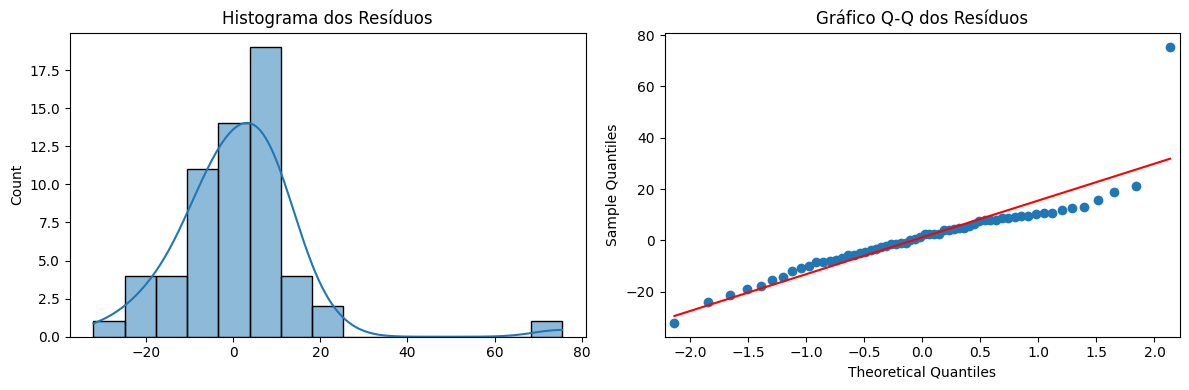

In [17]:
# Histograma e Gráfico Q-Q (Quantile-Quantile)

import statsmodels.api as sm

# Cria uma figura com 2 subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
sns.histplot(residuos, kde=True, label='Resíduos', ax=ax1)
ax1.set_title('Histograma dos Resíduos')

# Gráfico Q-Q
sm.qqplot(residuos, line='s', ax=ax2)
ax2.set_title('Gráfico Q-Q dos Resíduos')

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.show()


Observações

Histograma dos Resíduos:
- Observa-se que a distribuição se aproxima de uma forma de sino, que é característica de uma distribuição normal;
- No entanto, há uma cauda à direita (valores atípicos positivos) que se desvia um pouco da normalidade perfeita;
- O histograma sugere que os resíduos têm uma distribuição aproximadamente normal, mas com algumas irregularidades, especialmente na cauda direita.

Gráfico Q-Q dos Resíduos:
- Se os resíduos fossem perfeitamente normais, os pontos se alinhar-iam perfeitamente ao longo da linha vermelha;
- A maior parte dos pontos segue a linha vermelha de forma razoável, indicando que a distribuição dos resíduos é aproximadamente normal.
- Na extremidade direita, há um ponto que se desvia significativamente da linha, o que corresponde à cauda observada no histograma;

O histograma e o gráfico Q-Q confirmam que a distribuição dos resíduos é aproximadamente normal, mas com algumas irregularidades, especialmente na cauda direita.

In [18]:
from scipy import stats

# Teste de Shapiro-Wilk
stat, p = stats.shapiro(residuos)
print(f'Teste de Shapiro-Wilk: Estatística = {stat:.3f}, p = {p:.3f}')

# Teste de Kolmogorov-Smirnov
stat, p = stats.kstest(residuos, 'norm')
print(f'Teste de Kolmogorov-Smirnov: Estatística = {stat:.3f}, p = {p:.3f}')

# Teste de Anderson-Darling
result = stats.anderson(residuos, dist='norm')
print(f'Teste de Anderson-Darling: Estatística = {result.statistic:.3f}') # type: ignore
for i in range(len(result.critical_values)): # type: ignore
    sl, cv = result.significance_level[i], result.critical_values[i] # type: ignore
    print(f'Nível de Significância {sl:.1f} %: Crítico = {cv:.3f}, Resultado: {result.statistic < cv}') # type: ignore


Teste de Shapiro-Wilk: Estatística = 0.836, p = 0.000
Teste de Kolmogorov-Smirnov: Estatística = 0.492, p = 0.000
Teste de Anderson-Darling: Estatística = 1.514
Nível de Significância 15.0 %: Crítico = 0.544, Resultado: False
Nível de Significância 10.0 %: Crítico = 0.619, Resultado: False
Nível de Significância 5.0 %: Crítico = 0.743, Resultado: False
Nível de Significância 2.5 %: Crítico = 0.866, Resultado: False
Nível de Significância 1.0 %: Crítico = 1.030, Resultado: False


Observações

Estatística de Teste (stat):
- A estatística de teste de Shapiro-Wilk varia entre 0 e 1;
- Valores próximos de 1 indicam que os dados se ajustam bem a uma distribuição normal;
- Valores mais baixos indicam desvios da normalidade.

P-valor (p):
- O p-valor indica a probabilidade de observar a estatística de teste (ou uma mais extrema) se os dados fossem realmente provenientes de uma distribuição normal;
- Se o p-valor for menor que um nível de significância predefinido (geralmente 0,05), rejeitamos a hipótese nula de que os dados são normalmente distribuídos;
- Se o p-valor for maior que o nível de significância, não rejeitamos a hipótese nula e concluímos que não há evidências suficientes para rejeitar a normalidade dos dados.

Teste de Anderson-Darling:
- Valores críticos têm de ser maiores que o valor da estatística de teste para a hipótese nula de normalidade ser rejeitada.

Em todos os testes o resultado é de rejeitar a hipótese nula de que os resíduos seguem uma distribuição normal.  
Isso indica fortemente que os resíduos do modelo não são normalmente distribuídos.  

A cauda à direita observada no histograma e os desvios no gráfico Q-Q são confirmados pelos testes estatísticos, que rejeitam fortemente a hipótese de normalidade.
Isto indica que existem valores atípicos, que afectam a normalidade dos residuos.   


3. Homocedásticos (variância constante ao longo do tempo)

    Homocedasticidade significa que a variância dos resíduos é constante, ou seja, ela não muda significativamente ao longo do tempo ou em relação aos valores previstos pelo modelo. Em termos mais simples, os erros têm a mesma "quantidade de variação" em todas as partes do conjunto de dados. 

    A variância dos resíduos mede o quão dispersos ou espalhados esses erros estão em torno da média (que, idealmente, deve ser zero).
    Uma alta variância indica que os erros são muito variáveis, enquanto uma baixa variância indica que os erros são mais consistentes.  

    A homocedasticidade garante que a precisão do modelo seja consistente em todo o intervalo de valores previstos e ao longo do tempo. A heterocedasticidade, por outro lado, indica que a precisão do modelo varia, o que pode levar a conclusões incorretas.

3. Métodos de detecção  

    - Métodos Visuais:  
        - Gráfico de Dispersão dos Resíduos vs. Tempo  
            - Uma dispersão constante ao longo do tempo sugere homocedasticidade;  
            - Variações na dispersão ao longo do tempo indicam heterocedasticidade.  
    - Métodos Estatísticos:  
        - Teste de Breusch-Pagan  
            - Este teste verifica se a variância dos resíduos depende das variáveis independentes;  
            - A hipótese nula é que a variância dos resíduos é constante (homocedasticidade);  
            - Um p-valor baixo (menor que um nível de significância predefinido, como 0,05) indica heterocedasticidade.  
        - Teste de White:  
            - Este teste é mais geral e não assume a normalidade dos resíduos;  
            - Verifica se a variância dos resíduos está relacionada com os valores previstos, seus quadrados e produtos cruzados;  
            - Semelhante ao teste de Breusch-Pagan, um p-valor baixo indica heterocedasticidade.  


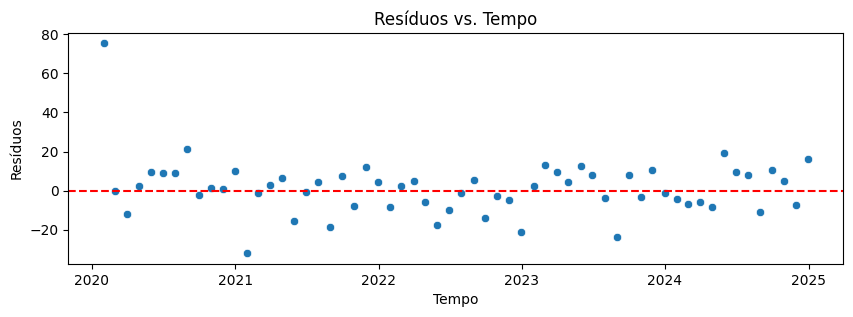

In [19]:
# Gráfico de Dispersão dos Resíduos vs. Tempo
plt.figure(figsize=(10, 3))
sns.scatterplot(residuos)
plt.title('Resíduos vs. Tempo')
plt.xlabel('Tempo')
plt.ylabel('Resíduos')

# Linha horizontal em y=0
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [20]:
# Testes Estatísticos

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

# OS testes necessitam de pelo menos 2 variáveis independentes uma delas constante (geralmente uma coluna de uns)
petr4_media_mensal_w_constant = sm.add_constant(petr4_media_mensal)

# Teste de Breusch-Pagan
# LM = Multiplicador de Lagrange (Lagrange Multiplier)
bp_test = het_breuschpagan(residuos, petr4_media_mensal_w_constant)
print(f'Teste de Breusch-Pagan: LM = {bp_test[0]:.3f}, p-valor = {bp_test[1]:.3f}')

# Teste de White
white_test = het_white(residuos, petr4_media_mensal_w_constant)
print(f'Teste de White: LM = {white_test[0]:.3f}, p-valor = {white_test[1]:3f}')


Teste de Breusch-Pagan: LM = 3.277, p-valor = 0.070
Teste de White: LM = 5.654, p-valor = 0.059188


Observações

- Os testes estatísticos indicam uma situação ambígua em relação à homocedasticidade, com p-valores próximos de 0.05;
- O gráfico de dispersão sugere homocedasticidade visualmente, mas a presença do outlier levanta dúvidas;
- O outlier pode ter influenciado os resultados dos testes e a percepção visual da homocedasticidade;
- É recomendável investigar a causa do outlier e avaliar o impacto nos resultados do modelo.

4. Estacionariedade  
Uma série temporal é considerada estacionária quando suas propriedades estatísticas não mudam ao longo do tempo:
    - Média Constante: A média da série permanece a mesma, independentemente do período de tempo considerado;
    - Variância Constante: A dispersão dos dados não muda ao longo do tempo;
    - Autocorrelação Constante: A relação entre valores passados e futuros depende apenas da diferença de tempo (lag), não do momento em que se calcula.  

    A estacionariedade é crucial na análise de séries temporais por várias razões:  
    - Modelos estatísticos, como o ARIMA (AutoRegressive Integrated Moving Average), assumem que as séries temporais são estacionárias. Tornar uma série estacionária simplifica a modelagem e a sua previsão;  
    - Modelos construídos com base em séries estacionárias tendem a produzir previsões mais confiáveis, pois as propriedades estatísticas constantes permitem extrapolar padrões para o futuro;  
    - A estacionariedade facilita a identificação de padrões subjacentes nos dados, como sazonalidade e ciclos, que podem ser obscurecidos em séries não estacionárias.  

    Existem várias maneiras de verificar a estacionariedade de uma série temporal:  
    - Visual - Gráficos da série temporal podem revelar tendências ou sazonalidade, que indicam não estacionariedade;
    - Estatísticas Descritivas - A média e a variância da série podem ser calculadas em diferentes períodos de tempo para verificar se são constantes;
    - Testes Estatísticos - Testes como o Teste de Dickey-Fuller Aumentado (ADF) e o Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin) podem ser usados para verificar formalmente a estacionariedade.  

    Se uma série temporal não for estacionária, existem técnicas para transformá-la em estacionária:  
    - A diferenciação envolve subtrair observações consecutivas para remover tendências e sazonalidade;  
    - Transformações logarítmicas podem ser usadas para estabilizar a variância;  
    - A decomposição sazonal separa a série em componentes de tendência, sazonalidade e resíduos, que podem ser analisados separadamente.

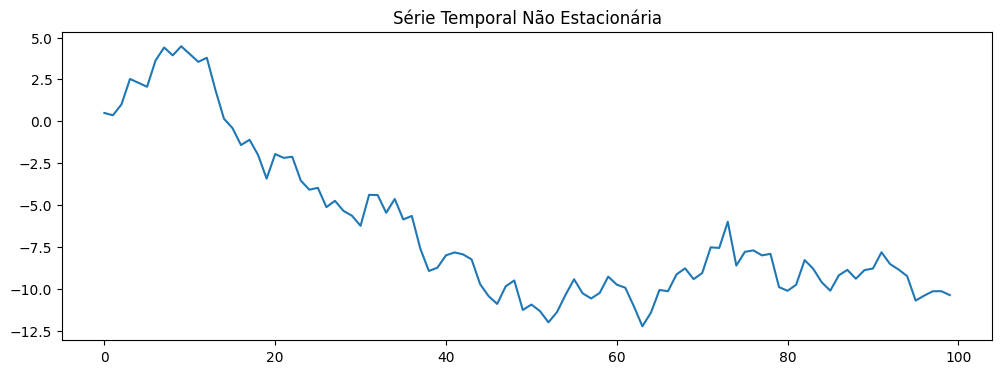

In [21]:
# Criar uma série temporal de exemplo (não estacionária)
np.random.seed(42)
time_series = pd.Series(np.cumsum(np.random.randn(100)))

# Inspeção Visual
plt.figure(figsize=(12, 4))
plt.plot(time_series)
plt.title("Série Temporal Não Estacionária")
plt.show()


In [22]:
from statsmodels.tsa.stattools import adfuller, kpss

# Teste ADF
result_ADF = adfuller(time_series)

# Exibir resultados
print('Teste ADF:')
print(f'Estatística ADF: {result_ADF[0]}')
print(f'P-valor: {result_ADF[1]}')
print(f'Número de Lags Usados: {result_ADF[2]}')
print(f'Número de Observações Usadas: {result_ADF[3]}')
for key, value in result_ADF[4].items(): # type: ignore
    print(f'Nível de Significância {key}: Valor Crítico = {value:.3f}')


# Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin)
# 'c' para teste em torno de uma constante
result_KPSS = kpss(time_series, regression='c')

# Exibir resultados
print('\nTeste KPSS:')
print(f'Estatística KPSS: {result_KPSS[0]}')
print(f'P-valor: {result_KPSS[1]}')
print(f'Lags Usados: {result_KPSS[2]}')
for key, value in result_KPSS[3].items(): # type: ignore
    print(f'Nível de Significância {key}: Valor Crítico = {value:.3f}')



Teste ADF:
Estatística ADF: -1.3583317659818985
P-valor: 0.6020814791099101
Número de Lags Usados: 0
Número de Observações Usadas: 99
Nível de Significância 1%: Valor Crítico = -3.498
Nível de Significância 5%: Valor Crítico = -2.891
Nível de Significância 10%: Valor Crítico = -2.583

Teste KPSS:
Estatística KPSS: 1.2573035522875027
P-valor: 0.01
Lags Usados: 5
Nível de Significância 10%: Valor Crítico = 0.347
Nível de Significância 5%: Valor Crítico = 0.463
Nível de Significância 2.5%: Valor Crítico = 0.574
Nível de Significância 1%: Valor Crítico = 0.739


C:\Users\utilizador\AppData\Local\Temp\ipykernel_19664\4291586355.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_KPSS = kpss(time_series, regression='c')


Observações  

Teste ADF:
- Estatística ADF - -1.358;  
- P-valor - 0.602;  
- A série temporal é não estacionária. O p-valor é muito maior que 0.05, e a estatística ADF é maior que todos os valores críticos.  

Teste KPSS:  
- Estatística KPSS - 1.257;  
- P-valor - 0.01;  
- A série temporal é não estacionária em torno de uma tendência. O p-valor é menor que 0.05, e a estatística KPSS é maior que todos os valores críticos.  

Ambos os testes indicam que a série temporal não é estacionária.  
O teste ADF indica que a série não é estacionária em geral.  
O teste KPSS indica que a série não é estacionária em torno de uma tendência.  
Isto significa que a série temporal precisa de ser transformada para se tornar estacionária antes de se poder usar modelos estatisticos que precisem desta caracteristica.


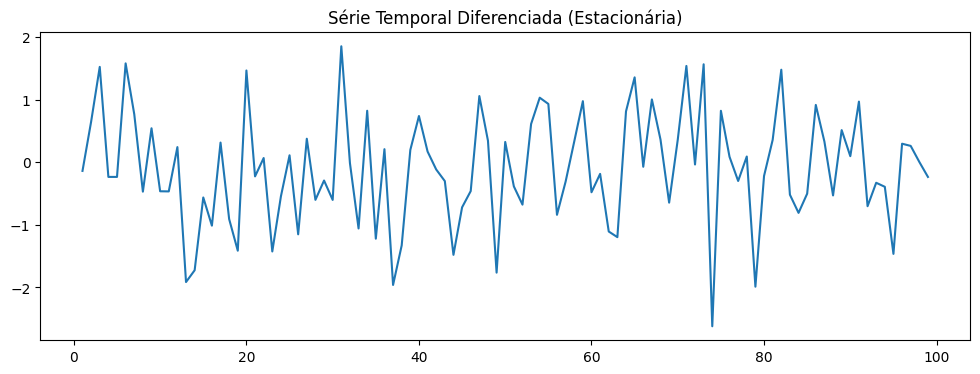

In [23]:
# Diferenciação
time_series_diff = time_series.diff().dropna()

# Inspeção Visual da Série Diferenciada
plt.figure(figsize=(12, 4))
plt.plot(time_series_diff)
plt.title("Série Temporal Diferenciada (Estacionária)")
plt.show()

In [24]:
# Teste ADF na Série Diferenciada
result_diff = adfuller(time_series_diff)
print("Teste ADF na Série Diferenciada:")
print(f"Estatística ADF: {result_diff[0]}")
print(f"P-valor: {result_diff[1]}")
print(f'Número de Observações Usadas: {result_ADF[3]}')
for key, value in result_diff[4].items(): # type: ignore
    print(f'Nível de Significância {key}: Valor Crítico = {value:.3f}')

Teste ADF na Série Diferenciada:
Estatística ADF: -10.008881137130237
P-valor: 1.800687720719554e-17
Número de Observações Usadas: 99
Nível de Significância 1%: Valor Crítico = -3.499
Nível de Significância 5%: Valor Crítico = -2.892
Nível de Significância 10%: Valor Crítico = -2.583


Observações

Os resultados do Teste ADF indicam fortemente que a série diferenciada é estacionária.  
O p-valor extremamente baixo e a estatística ADF altamente negativa fornecem evidências significativas para rejeitar a hipótese nula de não estacionariedade.  
A diferenciação foi eficaz em tornar a série temporal estacionária.

## Conclusão

Neste notebook, exploramos as principais características associadas à análise de séries temporais, oferecendo uma visão geral dos conceitos e técnicas fundamentais.  
Desde o estudo das tendências até a avaliação da estacionariedade, abordamos métodos para realizar uma análise cuidadosa das séries temporais.  
É importante ressaltar que este notebook fornece uma visão geral, e que existem diversas abordagens e técnicas que podem ser aplicadas na análise de séries temporais, dependendo dos objetivos e das características específicas dos dados.